# HELLO!

This notebook combines the SolDet data with Bradley's simulations to force LeViT, a vision based transformer to do what it was not intended to do :)

I started first without the simulations working on the structure of the Classifier program. However it became clear very fast that the low amount of trianing data was a huge issue and the accuracy peaked at 85% for one lucky run but mostly stayed between 79-80%.  Mixing-in some simulation data to the training set has helped bring this up to 90-92%. (Hopefully there are outputs to display in this notebook to show the plots, matric and ROC.)

General structure:

**1. Classifier - Is there a soliton?**
- LeViT-192 pretrained on ImageNet, converted to 1-channel input by averaging RGB weights.

- Adapter layer (192-dim) between frozen backbone and classifier head

  
- Two-phase training: frozen backbone --> full fine-tuning


- Trained on mixed data (real + cGAN simulated images)


- 3-class output: No soliton / Single soliton / Other


- 5-fold CV with validation (DID NOT ATTEMPT due to time constraints and kaggle crashing out when left unsupervised, BUT THE CODE IS THERE)




In [1]:
#!pip install timm torch torchvision seaborn scikit-learn
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import random
import os
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import timm

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import label_binarize

plt.style.use('default')
sns.set_palette("husl")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}, timm: {timm.__version__}, Device: {device}")



PyTorch: 2.10.0+cu128, timm: 1.0.25, Device: cuda


In [2]:
from pathlib import Path

# folder where this script is located
#PROJECT_ROOT = Path().resolve()  # current working directory
DATA_DIR = Path('/kaggle/input/datasets/archiesrikumar/bec-dataset/data')
DATA_FILES_DIR = DATA_DIR / 'data_files'
LABELS_FILE = DATA_DIR / 'data_info' / 'data_info' /'data_roster.csv'

print(DATA_FILES_DIR.exists())  # should be True
print(LABELS_FILE.exists())     # should be True
labels_df = pd.read_csv(LABELS_FILE, index_col=0)

def load_bec_dataset(data_dir, labels_df, max_samples=None, shuffle_seed=42):
    class_dirs = sorted(
        [d for d in data_dir.glob('class-*') if d.is_dir()],
        key=lambda p: int(p.name.split('-')[-1]) if p.name.split('-')[-1].isdigit() else 0
    )
    all_files = []
    for cd in class_dirs:
        all_files.extend(sorted(cd.glob('*.npy')))
    
    if shuffle_seed is not None:
        random.seed(shuffle_seed)
        random.shuffle(all_files)
    if max_samples:
        all_files = all_files[:max_samples]

    images, labels_list, positions_list = [], [], []
    for fp in tqdm(all_files, desc="Loading"):
        try:
            d = np.load(fp, allow_pickle=True).item()
            img = d['masked_data'].reshape(132, 164, 1)
            rel = '/data/' + '/'.join(fp.parts[-3:])
            if rel in labels_df.index:
                row = labels_df.loc[rel]
                label = int(row['label_v3'])
                pos_str = row['excitation_position']
                pos = []
                if not pd.isna(pos_str) and pos_str != '':
                    try:
                        pos = eval(pos_str) if isinstance(pos_str, str) else []
                        if not isinstance(pos, list):
                            pos = [pos] if pos else []
                    except:
                        pos = []
                images.append(img)
                labels_list.append(label)
                positions_list.append(pos)
        except Exception as e:
            print(f"Error: {fp}: {e}")

    images = np.array(images, dtype=np.float32)
    labels_arr = np.array(labels_list, dtype=np.int32)
    print(f"Loaded {len(images)} images {images.shape}")
    return images, labels_arr, positions_list

images, labels, positions = load_bec_dataset(DATA_FILES_DIR, labels_df, max_samples=None) #max_samples is None for full data set

True
True


Loading: 100%|██████████| 16478/16478 [04:08<00:00, 66.29it/s]


Loaded 16478 images (16478, 132, 164, 1)


# CLASSIFIER

In [14]:

#  Filter and Split
valid = labels < 8
images_f = images[valid]
labels_f = labels[valid].copy()
positions_f = [positions[i] for i in range(len(positions)) if valid[i]]

labels_f[labels_f >= 2] = 2
print(f"Filtered: {len(images_f)}, distribution: {np.bincount(labels_f)}")

X_train, X_test, y_train, y_test, pos_train, pos_test = train_test_split(
    images_f, labels_f, positions_f,
    test_size=0.2, random_state=42, stratify=labels_f
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Train dist: {np.bincount(y_train)}, Test dist: {np.bincount(y_test)}")



Filtered: 5378, distribution: [1130 3212 1036]
Train: 4302, Test: 1076
Train dist: [ 904 2569  829], Test dist: [226 643 207]


In [15]:
# Generator Setup + Load
USE_EXCITATION_QUALITY_IN_C = True
MASK_SOLITON_X_WITH_VALID = True
NUM_CLASSES = 3
LATENT_DIM = 128
COND_DIM = 6
EMBED_DIM = 32
DEVICE = device


class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim, embed_dim, base_channels=128):
        super().__init__()
        self.cond_embed = nn.Sequential(
            nn.Linear(cond_dim, embed_dim),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.init_h = 33
        self.init_w = 41
        self.init_channels = base_channels
        self.fc = nn.Linear(latent_dim + embed_dim,
                            base_channels * self.init_h * self.init_w)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(base_channels, base_channels // 2,
                               kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(base_channels // 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(base_channels // 2, base_channels // 4,
                               kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(base_channels // 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels // 4, 1, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, z, cond):
        cond_feat = self.cond_embed(cond)
        x = torch.cat([z, cond_feat], dim=1)
        x = self.fc(x)
        x = x.view(x.size(0), self.init_channels, self.init_h, self.init_w)
        return self.net(x)


def make_condition_tensor(class_idx, position=0.0, valid_excitation=None,
                          quality=1.0, batch_size=1, device=None):
    if valid_excitation is None:
        valid_excitation = 1.0 if class_idx == 1 else 0.0
    c = torch.zeros((batch_size, COND_DIM), dtype=torch.float32, device=device)
    c[:, class_idx] = 1.0
    c[:, 3] = float(np.clip(position, -1.0, 1.0))
    c[:, 4] = 1.0 if float(valid_excitation) >= 0.5 else 0.0
    c[:, 5] = float(np.clip(quality, 0.0, 1.0))
    if MASK_SOLITON_X_WITH_VALID:
        c[:, 3] = c[:, 3] * c[:, 4]
    if not USE_EXCITATION_QUALITY_IN_C:
        c[:, 5] = 0.0
    return c


g = Generator(LATENT_DIM, COND_DIM, EMBED_DIM).to(DEVICE)
ckpt = torch.load(
    "/kaggle/input/models/archiesrikumar/simulate-bradley/pytorch/default/1/cgan_100.pt",
    map_location=DEVICE
)
g.load_state_dict(ckpt["g_state"])
g.eval()
print("Generator loaded.")

Generator loaded.


In [24]:
# Generate Simulated Dataset

@torch.no_grad()
def generate_dataset(generator, n_per_class, device):
    all_images = []
    all_labels = []

    for cls in range(3):
        print(f"  Generating class {cls}: {n_per_class} samples...")
        batch_size = 64
        n_generated = 0

        while n_generated < n_per_class:
            current_batch = min(batch_size, n_per_class - n_generated)
            z = torch.randn(current_batch, LATENT_DIM, device=device)

            if cls == 1:
                positions = np.random.uniform(-0.8, 0.8, current_batch)
                qualities = np.random.uniform(0.5, 1.0, current_batch)
            else:
                positions = np.zeros(current_batch)
                qualities = np.ones(current_batch)

            conds = []
            for i in range(current_batch):
                c = make_condition_tensor(
                    class_idx=cls,
                    position=float(positions[i]),
                    quality=float(qualities[i]),
                    device=device,
                )
                conds.append(c)
            cond_batch = torch.cat(conds, dim=0)

            imgs = generator(z, cond_batch)
            imgs_np = imgs.cpu().numpy().transpose(0, 2, 3, 1)

            all_images.append(imgs_np)
            all_labels.extend([cls] * current_batch)
            n_generated += current_batch

    sim_images = np.concatenate(all_images, axis=0).astype(np.float32)
    sim_labels = np.array(all_labels, dtype=np.int32)

    perm = np.random.permutation(len(sim_images))
    sim_images = sim_images[perm]
    sim_labels = sim_labels[perm]

    print(f"\nGenerated {len(sim_images)} images, shape: {sim_images.shape}")
    print(f"Distribution: {np.bincount(sim_labels)}")
    print(f"Range: [{sim_images.min():.3f}, {sim_images.max():.3f}]")
    return sim_images, sim_labels


N_PER_CLASS = 1000
print("Generating simulated dataset...")
sim_images_raw, sim_labels = generate_dataset(g, N_PER_CLASS, DEVICE)

Generating simulated dataset...
  Generating class 0: 1000 samples...
  Generating class 1: 1000 samples...
  Generating class 2: 1000 samples...

Generated 3000 images, shape: (3000, 132, 164, 1)
Distribution: [1000 1000 1000]
Range: [-0.991, 0.972]


In [93]:
# Generate UNBALANCED Simulated Data (More "Other")

@torch.no_grad()
def generate_single_class(generator, cls: int, n_samples: int, device):
    """Generate samples for only one class."""
    images = []
    labels = []
    batch_size = 64
    generated = 0

    while generated < n_samples:
        current = min(batch_size, n_samples - generated)
        z = torch.randn(current, LATENT_DIM, device=device)

        if cls == 1:
            positions = np.random.uniform(-0.8, 0.8, current)
            qualities = np.random.uniform(0.6, 1.0, current)
        else:
            positions = np.zeros(current)
            qualities = np.ones(current)

        conds = []
        for i in range(current):
            c = make_condition_tensor(
                class_idx=cls,
                position=float(positions[i]),
                quality=float(qualities[i]),
                device=device
            )
            conds.append(c)
        cond_batch = torch.cat(conds, dim=0)

        imgs = generator(z, cond_batch)
        imgs_np = imgs.cpu().numpy().transpose(0, 2, 3, 1)   # (B, H, W, 1)

        images.append(imgs_np)
        labels.extend([cls] * current)
        generated += current

    return np.concatenate(images, axis=0).astype(np.float32), np.array(labels, dtype=np.int32)


# ==================== Generate Unbalanced Dataset ====================

print("Generating unbalanced simulated data...")

sim_images_0, sim_labels_0 = generate_single_class(g, cls=0, n_samples=600, device=DEVICE)
sim_images_1, sim_labels_1 = generate_single_class(g, cls=1, n_samples=1200, device=DEVICE)
sim_images_2, sim_labels_2 = generate_single_class(g, cls=2, n_samples=1800, device=DEVICE)  # More "Other"

# Combine
sim_images_raw = np.concatenate([sim_images_0, sim_images_1, sim_images_2], axis=0)
sim_labels = np.concatenate([sim_labels_0, sim_labels_1, sim_labels_2], axis=0)

# Shuffle
perm = np.random.permutation(len(sim_images_raw))
sim_images_raw = sim_images_raw[perm]
sim_labels = sim_labels[perm]

print(f"Generated unbalanced simulated dataset: {len(sim_images_raw)} images")
print(f"Distribution: {np.bincount(sim_labels)}  (Class 0, 1, 2)")

Generating unbalanced simulated data...
Generated unbalanced simulated dataset: 3600 images
Distribution: [ 600 1200 1800]  (Class 0, 1, 2)


In [94]:
# ============================================================
# Cell 6: Normalize Simulated to Match Real
# ============================================================
real_mean = X_train.mean()
real_std = X_train.std()
sim_mean = sim_images_raw.mean()
sim_std = sim_images_raw.std()

sim_images = (sim_images_raw - sim_mean) / (sim_std + 1e-8)
sim_images = sim_images * real_std + real_mean

print(f"Real:       mean={real_mean:.4f} std={real_std:.4f} range=[{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"Sim (norm): mean={sim_images.mean():.4f} std={sim_images.std():.4f} range=[{sim_images.min():.3f}, {sim_images.max():.3f}]")
plt.show()

Real:       mean=0.2090 std=0.3009 range=[-0.473, 2.965]
Sim (norm): mean=0.2090 std=0.3009 range=[-0.218, 1.346]


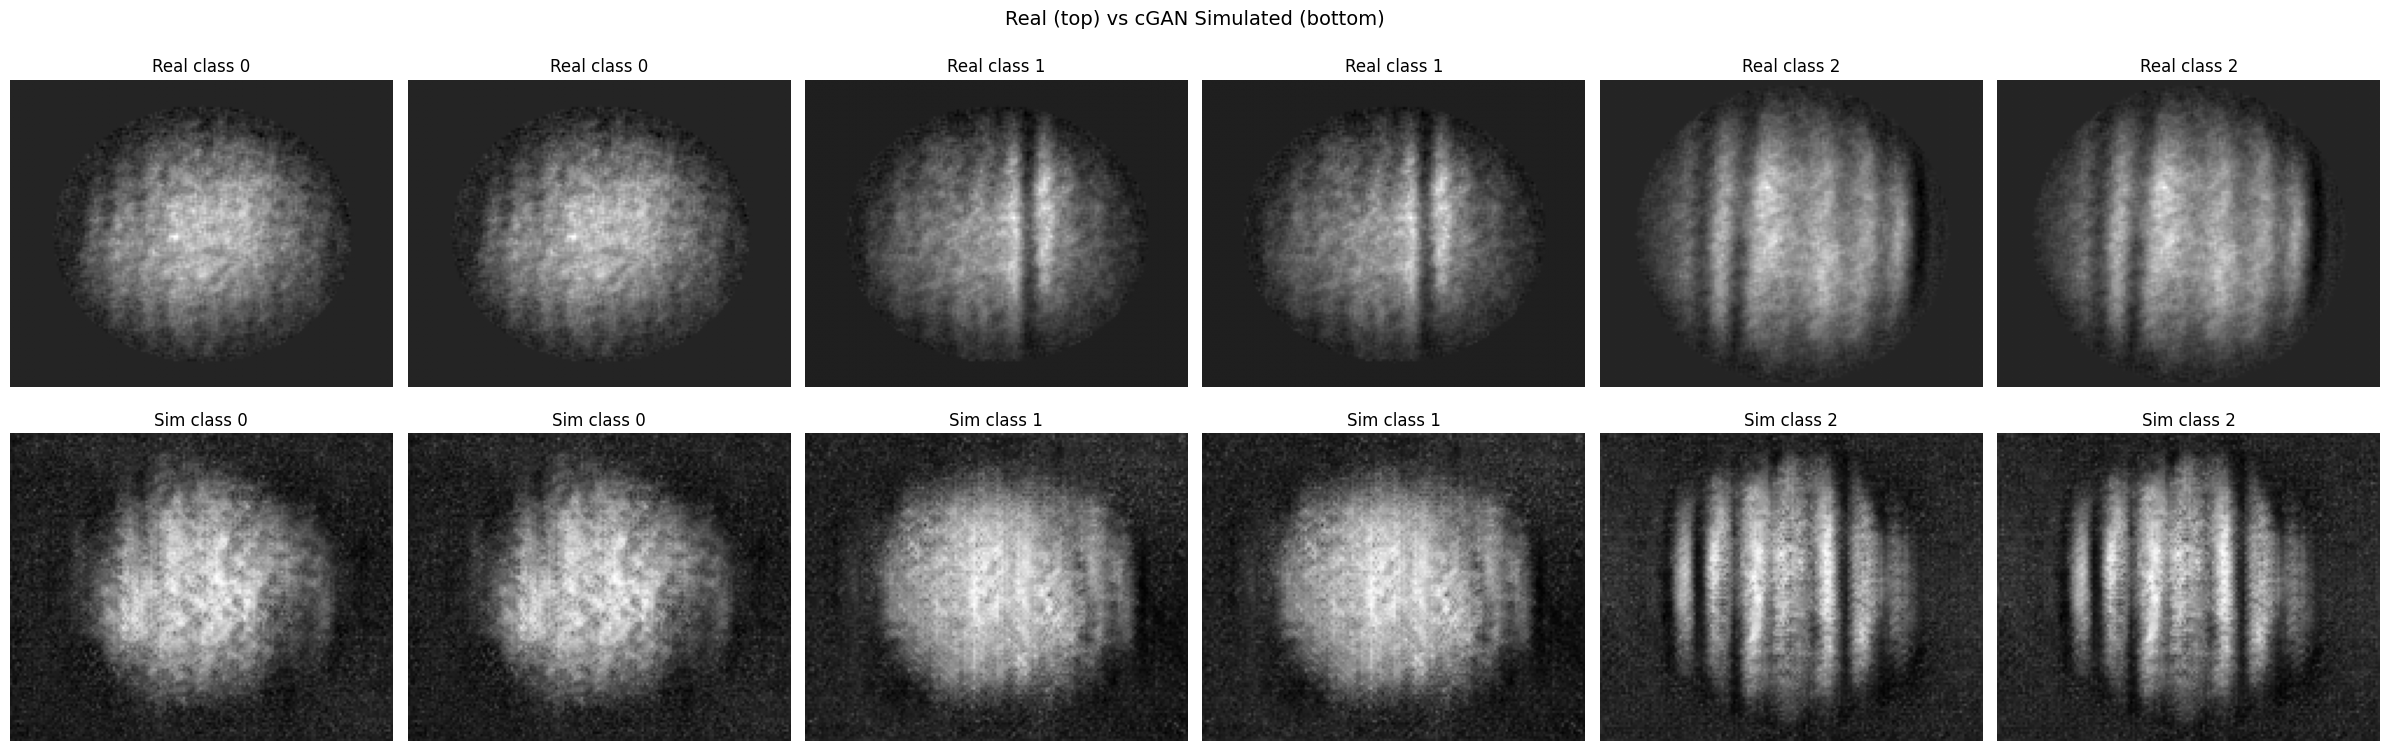

In [95]:
# ============================================================
# Cell 7: Visual Check
# ============================================================
fig, axes = plt.subplots(2, 6, figsize=(24, 8))

for i, cls in enumerate([0, 0, 1, 1, 2, 2]):
    matches = np.where(y_train == cls)[0]
    idx = matches[i // 2]
    axes[0, i].imshow(X_train[idx].squeeze(), cmap='gray')
    axes[0, i].set_title(f'Real class {cls}')
    axes[0, i].axis('off')

for i, cls in enumerate([0, 0, 1, 1, 2, 2]):
    matches = np.where(sim_labels == cls)[0]
    idx = matches[i // 2]
    axes[1, i].imshow(sim_images[idx].squeeze(), cmap='gray')
    axes[1, i].set_title(f'Sim class {cls}')
    axes[1, i].axis('off')

plt.suptitle('Real (top) vs cGAN Simulated (bottom)', fontsize=14)
plt.tight_layout()
plt.show()

In [96]:
# ============================================================
# Cell 8: Dataset + Model + All Training Functions
# ============================================================

class BECDataset(Dataset):
    """1-channel dataset — flips only."""
    def __init__(self, images, labels, augment=False, target_size=(224, 224)):
        self.images = images
        self.labels = labels
        self.augment = augment
        self.target_size = target_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].transpose(2, 0, 1)
        if self.augment:
            if random.random() > 0.5:
                img = np.flip(img, axis=1).copy()
            if random.random() > 0.5:
                img = np.flip(img, axis=2).copy()
        t = torch.from_numpy(img.copy()).float()
        t = torch.nn.functional.interpolate(
            t.unsqueeze(0), size=self.target_size,
            mode='bilinear', align_corners=False
        ).squeeze(0)
        return t, int(self.labels[idx])


class LeViTWithAdapter(nn.Module):
    """Trainable adapter between frozen backbone and classifier."""
    def __init__(self, base_model, adapter_dim=192, num_classes=3):
        super().__init__()
        self.base_model = base_model
        feat_dim = base_model.num_features
        print(f"  Backbone feature dim: {feat_dim}")
        base_model.reset_classifier(0)
        self.adapter = nn.Sequential(
            nn.Linear(feat_dim, adapter_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(adapter_dim, adapter_dim),
            nn.GELU(),
            nn.Dropout(0.3),
        )
        self.classifier = nn.Linear(adapter_dim, num_classes)

    def forward(self, x):
        features = self.base_model(x)
        adapted = self.adapter(features)
        return self.classifier(adapted)


def create_levit_1ch(num_classes=3, model_name='levit_192.fb_dist_in1k',
                     freeze_backbone=True, adapter_dim=192):
    """Create 1ch LeViT with averaged weights and adapter."""
    model_3ch = timm.create_model(
        model_name, pretrained=True, num_classes=num_classes, in_chans=3
    )
    model_1ch = timm.create_model(
        model_name, pretrained=False, num_classes=num_classes, in_chans=1
    )
    state_3ch = model_3ch.state_dict()
    state_1ch = model_1ch.state_dict()
    for key in state_3ch:
        if key not in state_1ch:
            continue
        if state_3ch[key].shape == state_1ch[key].shape:
            state_1ch[key] = state_3ch[key]
        elif len(state_3ch[key].shape) == 4 and state_3ch[key].shape[1] == 3:
            state_1ch[key] = state_3ch[key].mean(dim=1, keepdim=True)
            print(f"  Averaged {key}: {state_3ch[key].shape} → {state_1ch[key].shape}")
    model_1ch.load_state_dict(state_1ch)
    model = LeViTWithAdapter(model_1ch, adapter_dim=adapter_dim, num_classes=num_classes)
    if freeze_backbone:
        for name, param in model.base_model.named_parameters():
            param.requires_grad = False
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{model_name} (1ch+adapter): {total:,} total, {trainable:,} trainable")
    return model


def unfreeze_model(model, backbone_lr=1e-5, head_lr=1e-4):
    """Unfreeze with differential LRs."""
    for p in model.parameters():
        p.requires_grad = True
    backbone_params, adapter_params, head_params = [], [], []
    for name, p in model.named_parameters():
        if 'classifier' in name:
            head_params.append(p)
        elif 'adapter' in name:
            adapter_params.append(p)
        else:
            backbone_params.append(p)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Unfrozen: {trainable:,} trainable parameters")
    return [
        {'params': backbone_params, 'lr': backbone_lr},
        {'params': adapter_params, 'lr': head_lr},
        {'params': head_params, 'lr': head_lr},
    ]


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_model(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        loss = criterion(out, labels)
        probs = torch.softmax(out, dim=1)
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

In [97]:
# Cell: Mixed Training (sim + real combined)
# 
# # Only use 200 sim samples (less than real data)
# # so real data dominates the training signal
# N_PER_CLASS = 100  # 300 total, less than real data
# sim_images_small, sim_labels_small = generate_dataset(g, N_PER_CLASS, DEVICE)

# # Normalize
# sim_small_norm = (sim_images_small - sim_images_small.mean()) / (sim_images_small.std() + 1e-8)
# sim_small_norm = sim_small_norm * real_std + real_mean

# X_train_mixed = np.concatenate([X_train, sim_small_norm], axis=0)
# y_train_mixed = np.concatenate([y_train, sim_labels_small], axis=0)
# print(f"Mixed: {len(X_train_mixed)} (real={len(X_train)}, sim={len(sim_small_norm)})")

# Combine simulated and real
X_train_mixed = np.concatenate([X_train, sim_images], axis=0)
y_train_mixed = np.concatenate([y_train, sim_labels], axis=0)

print(f"Mixed training set: {len(X_train_mixed)} samples")
print(f"  Real: {len(X_train)}")
print(f"  Simulated: {len(sim_images)}")
print(f"  Distribution: {np.bincount(y_train_mixed)}")

# Use your existing two_phase_train
model = create_levit_1ch(
    num_classes=3, model_name='levit_192.fb_dist_in1k',
    freeze_backbone=True, adapter_dim=192
).to(device)

mixed_ds = BECDataset(X_train_mixed, y_train_mixed, augment=True)
test_ds = BECDataset(X_test, y_test, augment=False)

mixed_loader = DataLoader(mixed_ds, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)


def two_phase_train(model, train_loader, val_loader, device,
                    phase1_epochs=20, phase2_epochs=50,
                    phase1_lr=1e-3, phase2_backbone_lr=1e-5, phase2_head_lr=1e-4):
    # Class weights
    all_labels = []
    for _, labels in train_loader:
        all_labels.extend(labels.numpy())
    counts = np.bincount(all_labels)
    weights = 1.0 / counts
    weights = weights / weights.sum() * len(counts)
    criterion = nn.CrossEntropyLoss(
        weight=torch.FloatTensor(weights).to(device)
    )

    history = {'phase': [], 'epoch': [], 'train_loss': [], 'train_acc': [],
               'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    best_state = None
    patience_counter = 0
    PATIENCE = 15

    # Phase 1
    print("Phase 1: Head + adapter only")
    opt = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=phase1_lr, weight_decay=1e-4
    )
    sched1 = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=phase1_epochs, eta_min=phase1_lr * 0.01
    )

    for epoch in range(phase1_epochs):
        tl, ta = train_epoch(model, train_loader, criterion, opt, device)
        vl, va, _, _, _ = eval_model(model, val_loader, criterion, device)
        sched1.step()

        history['phase'].append(1)
        history['epoch'].append(epoch)
        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)

        if va > best_val_acc:
            best_val_acc = va
            best_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 5 == 0:
            print(f"  {epoch+1}/{phase1_epochs} | "
                  f"train={ta:.4f} val={va:.4f} | "
                  f"lr={opt.param_groups[0]['lr']:.2e}")

    # Phase 2
    print(f"\nPhase 2: Full fine-tuning")
    model.load_state_dict(best_state)
    param_groups = unfreeze_model(model, phase2_backbone_lr, phase2_head_lr)
    opt = optim.AdamW(param_groups, weight_decay=1e-4)
    sched2 = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=phase2_epochs, eta_min=phase2_backbone_lr * 0.01
    )
    patience_counter = 0

    for epoch in range(phase2_epochs):
        tl, ta = train_epoch(model, train_loader, criterion, opt, device)
        vl, va, _, _, _ = eval_model(model, val_loader, criterion, device)
        sched2.step()

        history['phase'].append(2)
        history['epoch'].append(phase1_epochs + epoch)
        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)

        if va > best_val_acc:
            best_val_acc = va
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

        if (epoch + 1) % 5 == 0:
            print(f"  {epoch+1}/{phase2_epochs} | "
                  f"train={ta:.4f} val={va:.4f} | "
                  f"backbone_lr={opt.param_groups[0]['lr']:.2e}")

    model.load_state_dict(best_state)
    print(f"\nBest val accuracy: {best_val_acc:.4f}")
    return history



Mixed training set: 7902 samples
  Real: 4302
  Simulated: 3600
  Distribution: [1504 3769 2629]
  Averaged stem.conv1.linear.weight: torch.Size([24, 3, 3, 3]) → torch.Size([24, 1, 3, 3])
  Backbone feature dim: 384
levit_192.fb_dist_in1k (1ch+adapter): 10,286,656 total, 111,555 trainable


In [98]:

#history = two_phase_train(model, mixed_loader, test_loader, device)
history = two_phase_train(
    model, mixed_loader, test_loader, device,
    phase1_epochs=30,
    phase2_epochs=50,
    phase1_lr=1e-3, #e-3
    phase2_backbone_lr=5e-6,   # 1e-5, reduce val loss spikes?
    phase2_head_lr=1e-4, #-4       
)
#criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(label_smoothing=0.2)
_, acc, y_pred, y_true, y_probs = eval_model(model, test_loader, criterion, device)
print(f"\nMixed training accuracy: {acc:.4f}")
print(classification_report(y_true, y_pred, digits=4,
      target_names=['No soliton', 'Single', 'Other']))

Phase 1: Head + adapter only
  5/30 | train=0.8393 val=0.7853 | lr=9.34e-04
  10/30 | train=0.8452 val=0.7760 | lr=7.53e-04
  15/30 | train=0.8599 val=0.7881 | lr=5.05e-04
  20/30 | train=0.8602 val=0.7974 | lr=2.58e-04
  25/30 | train=0.8757 val=0.7881 | lr=7.63e-05
  30/30 | train=0.8651 val=0.7900 | lr=1.00e-05

Phase 2: Full fine-tuning
Unfrozen: 10,286,656 trainable parameters
  5/50 | train=0.8951 val=0.8513 | backbone_lr=4.88e-06
  10/50 | train=0.9188 val=0.8643 | backbone_lr=4.53e-06
  15/50 | train=0.9274 val=0.8885 | backbone_lr=3.98e-06
  20/50 | train=0.9394 val=0.9099 | backbone_lr=3.29e-06
  25/50 | train=0.9489 val=0.9089 | backbone_lr=2.53e-06
  30/50 | train=0.9506 val=0.9164 | backbone_lr=1.76e-06
  35/50 | train=0.9571 val=0.9136 | backbone_lr=1.07e-06
  40/50 | train=0.9580 val=0.9191 | backbone_lr=5.23e-07
  Early stopping at epoch 44

Best val accuracy: 0.9219

Mixed training accuracy: 0.9210
              precision    recall  f1-score   support

  No soliton    

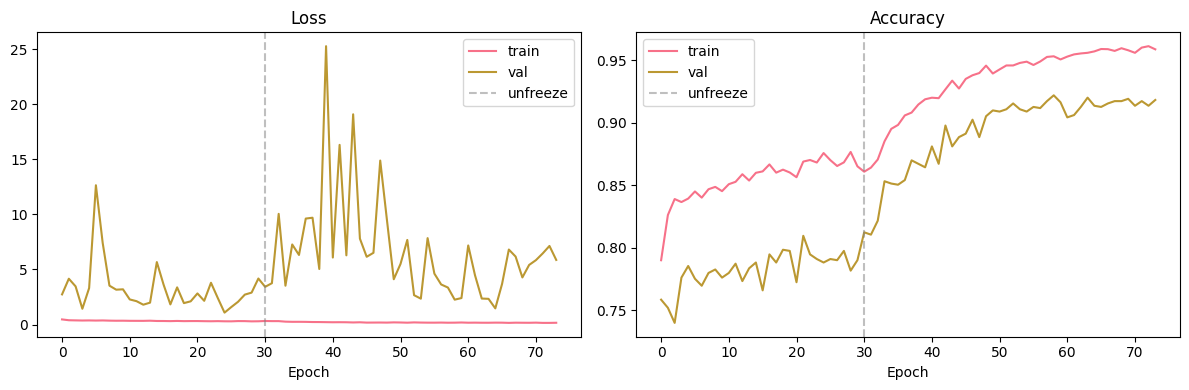

In [99]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
phase1_end = sum(1 for p in history['phase'] if p == 1)

for ax, metric, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
    #ax.set_yscale('log')
    ax.plot(history[f'train_{metric}'], label='train')
    ax.plot(history[f'val_{metric}'], label='val')
    ax.axvline(x=phase1_end, color='gray', ls='--', alpha=0.5, label='unfreeze')
    ax.set_xlabel('Epoch')
    ax.set_title(title)
    ax.legend()

plt.savefig("Levitganlossvalbester.png", dpi=300)
plt.tight_layout()
plt.show()

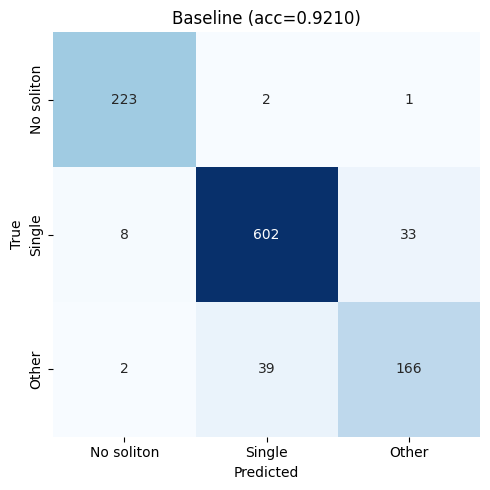

In [100]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No soliton', 'Single', 'Other'],
            yticklabels=['No soliton', 'Single', 'Other'])

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Baseline (acc={acc:.4f})')
plt.tight_layout()
plt.savefig("Levitgancmbester.png", dpi=300)
plt.show()


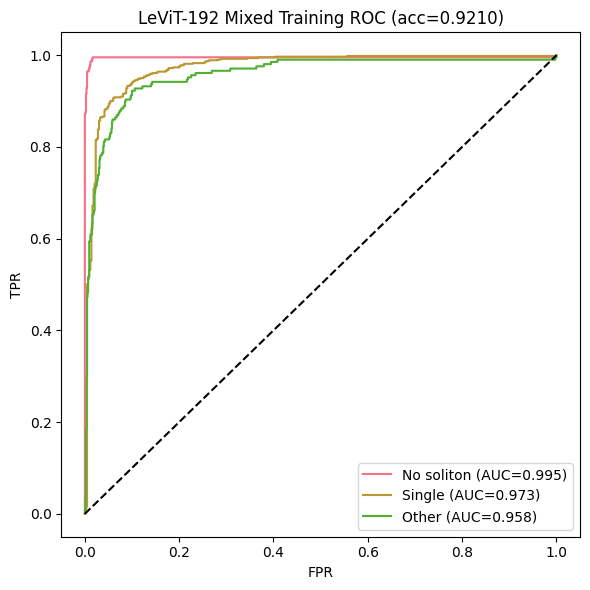

In [101]:
#roc
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

plt.figure(figsize=(6, 6))
for i, name in enumerate(['No soliton', 'Single', 'Other']):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    auc = roc_auc_score(y_true_bin[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'LeViT-192 Mixed Training ROC (acc={acc:.4f})')
plt.legend()
plt.tight_layout()
plt.savefig("bestroc.png")
plt.show()

## A note on this result


Best accuracy achieved: **92.1%** with mixed training (real + cGAN simulated data).

**Training curves:** The validation loss is extremely noisy - spiking up to 25 during phase 2 while train loss stays near zero. 

This is a sign of the backbone learning rate being slightly too aggressive when unfrozen, causing occasional large parameter updates that temporarily hurt validation performance. Despite this instability, the model recovers each time and validation accuracy 
trends upward, reaching ~92% by the end. 
The train-val accuracy gap (~95% vs 92%) suggests mild overfitting.

**Confusion matrix:** "No soliton" classification is near-perfect (223/226). "Single soliton" performs well (602/643, 93.6% recall) but 33 solitons get misclassified as "Other".

The weakest class remains "Other" (166/207, 80.2%) with 39 "Other" images being called "Single" — these are probably multi-soliton or 
vortex images where one feature dominates and looks like a single soliton. 

**ROC curves:** All three classes show strong discrimination with AUCs of 0.995 (No soliton), 0.973 (Single), and 0.958 (Other). The model is well-calibrated  in its probability outputs even where it makes classification errors.

**Context:** Without simulated data the model peaked at ~80% (CV mean). The cGAN simulations added ~3000 training samples which brought accuracy up by 12 percentage points — confirming that data scarcity, not model architecture, was the primary bottleneck.

In [102]:
torch.save(model.state_dict(), 'levit192_cganunbalanced-bester')
print("Saved final model")


Saved final model


In [106]:
# ============================================================
# 5-FOLD CV — Split REAL data only, add sim to each fold's train
# ============================================================
print("=" * 70)
print("5-FOLD CV: LeViT-192 + Adapter + Mixed Training")
print("  Folds split on REAL data only")
print("  Simulated data added to train every fold")
print("=" * 70)

N_FOLDS = 3
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_models = []
fold_results = []
criterion = nn.CrossEntropyLoss()

# Split only REAL data into folds
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f"\n{'='*70}")
    print(f"--- Fold {fold}/{N_FOLDS} ---")
    print(f"{'='*70}")

    # Real data split
    X_real_tr = X_train[train_idx]
    y_real_tr = y_train[train_idx]
    X_real_va = X_train[val_idx]     # validation is ONLY real
    y_real_va = y_train[val_idx]

    # # Add simulated to training only
    # X_fold_tr = np.concatenate([X_real_tr, sim_images], axis=0)
    # y_fold_tr = np.concatenate([y_real_tr, sim_labels], axis=0)

    SIM_RATIO = 0.25  # try 0.25, 0.5, 1.0

    n_real = len(X_real_tr)
    n_sim = int(SIM_RATIO * n_real)
    
    # sample without replacement
    sim_idx = np.random.choice(len(sim_images), n_sim, replace=False)
    
    X_sim_sampled = sim_images[sim_idx]
    y_sim_sampled = sim_labels[sim_idx]
    
    X_fold_tr = np.concatenate([X_real_tr, X_sim_sampled], axis=0)
    y_fold_tr = np.concatenate([y_real_tr, y_sim_sampled], axis=0)

    print(f"  Train: {len(X_fold_tr)} (real={len(X_real_tr)}, sim={len(sim_images)})")
    print(f"  Val:   {len(X_real_va)} (real only)")

    fold_train_ds = BECDataset(X_fold_tr, y_fold_tr, augment=True)
    fold_val_ds = BECDataset(X_real_va, y_real_va, augment=False)

    fold_train_loader = DataLoader(fold_train_ds, batch_size=16, shuffle=True, num_workers=2)
    fold_val_loader = DataLoader(fold_val_ds, batch_size=16, shuffle=False, num_workers=2)

    fold_model = create_levit_1ch(
        num_classes=3, model_name='levit_192.fb_dist_in1k',
        freeze_backbone=True, adapter_dim=192
    ).to(device)

    fold_history = two_phase_train(
        fold_model, fold_train_loader, fold_val_loader, device,
        phase1_epochs=30,
        phase2_epochs=50,
        phase1_lr=1e-3,
        phase2_backbone_lr=1e-6,
        phase2_head_lr=1e-4,
    )

    _, fold_acc, fold_preds, fold_labels, fold_probs = eval_model(
        fold_model, fold_val_loader, criterion, device
    )

    fold_models.append(fold_model)
    fold_results.append({'fold': fold, 'val_acc': fold_acc})
    print(f"Fold {fold} val accuracy: {fold_acc:.4f}")

# Summary
accs = [r['val_acc'] for r in fold_results]
print(f"\n{'='*70}")
print("5-FOLD CV SUMMARY")
print(f"{'='*70}")
print(f"Folds: {[f'{a:.4f}' for a in accs]}")
print(f"Mean:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Single split baseline: {acc:.4f}")

5-FOLD CV: LeViT-192 + Adapter + Mixed Training
  Folds split on REAL data only
  Simulated data added to train every fold

--- Fold 1/3 ---
  Train: 3585 (real=2868, sim=3600)
  Val:   1434 (real only)
  Averaged stem.conv1.linear.weight: torch.Size([24, 3, 3, 3]) → torch.Size([24, 1, 3, 3])
  Backbone feature dim: 384
levit_192.fb_dist_in1k (1ch+adapter): 10,286,656 total, 111,555 trainable
Phase 1: Head + adapter only
  5/30 | train=0.7609 val=0.7155 | lr=9.34e-04
  10/30 | train=0.7847 val=0.7036 | lr=7.53e-04
  15/30 | train=0.7986 val=0.7218 | lr=5.05e-04
  20/30 | train=0.7994 val=0.7308 | lr=2.58e-04
  25/30 | train=0.8064 val=0.7371 | lr=7.63e-05
  30/30 | train=0.8000 val=0.7497 | lr=1.00e-05

Phase 2: Full fine-tuning
Unfrozen: 10,286,656 trainable parameters
  5/50 | train=0.8145 val=0.7476 | backbone_lr=9.76e-07
  10/50 | train=0.8131 val=0.7510 | backbone_lr=9.05e-07
  15/50 | train=0.8209 val=0.7503 | backbone_lr=7.96e-07
  20/50 | train=0.8273 val=0.7768 | backbone_lr=6

Single split baseline: 0.9210
CV mean:               0.7927 ± 0.0132
Ensemble on test set:  0.8141

              precision    recall  f1-score   support

  No soliton     0.8441    0.9823    0.9080       226
      Single     0.8389    0.8663    0.8523       643
       Other     0.6510    0.4686    0.5449       207

    accuracy                         0.8141      1076
   macro avg     0.7780    0.7724    0.7684      1076
weighted avg     0.8038    0.8141    0.8049      1076



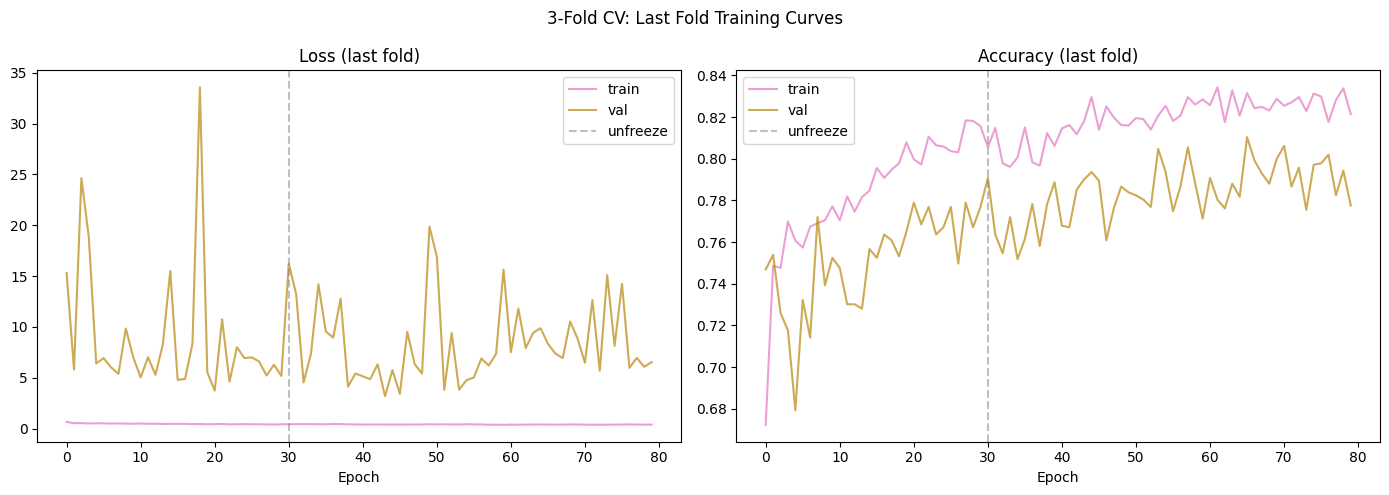

In [110]:
# ============================================================
# Ensemble Evaluation + All Plots
# ============================================================

# --- Ensemble Prediction ---
@torch.no_grad()
def ensemble_predict(models, loader, device):
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        batch_probs = []
        for m in models:
            m.eval()
            out = m(imgs)
            batch_probs.append(torch.softmax(out, dim=1).cpu().numpy())
        all_probs.extend(np.mean(batch_probs, axis=0))
        all_labels.extend(labels.numpy())
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = all_probs.argmax(axis=1)
    acc = (all_preds == all_labels).mean()
    return acc, all_preds, all_labels, all_probs

ens_acc, ens_preds, ens_labels, ens_probs = ensemble_predict(
    fold_models, test_loader, device
)

print(f"Single split baseline: {acc:.4f}")
print(f"CV mean:               {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Ensemble on test set:  {ens_acc:.4f}")
print(f"\n{classification_report(ens_labels, ens_preds, digits=4, target_names=['No soliton', 'Single', 'Other'])}")


# --- Training Curves (all folds overlaid) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

for i, result in enumerate(fold_results):
    h = fold_results[i].get('history', None)
    if h is None:
        # history not stored in fold_results, get from fold_histories if available
        continue

for fold_idx, fold_model in enumerate(fold_models):
    h = fold_results[fold_idx]
    # If histories were stored, plot them
    pass

# Plot each fold's history
for fold_idx in range(len(fold_results)):
    # Re-access histories if stored
    pass

# Simplified: plot last fold's history as representative
last_h = fold_history  # from the loop's last iteration
phase1_end = sum(1 for p in last_h['phase'] if p == 1)

for ax, metric, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
    ax.plot(last_h[f'train_{metric}'], label='train', alpha=0.7, color='tab:pink')
    ax.plot(last_h[f'val_{metric}'], label='val', alpha=0.7, color='darkgoldenrod')
    ax.axvline(x=phase1_end, color='gray', ls='--', alpha=0.5, label='unfreeze')
    ax.set_xlabel('Epoch')
    ax.set_title(f'{title} (last fold)')
    ax.legend()

plt.suptitle(f'{N_FOLDS}-Fold CV: Last Fold Training Curves', fontsize=12)
plt.tight_layout()
plt.savefig("ensembletraining_curves.png", dpi=300, bbox_inches='tight')
plt.show()

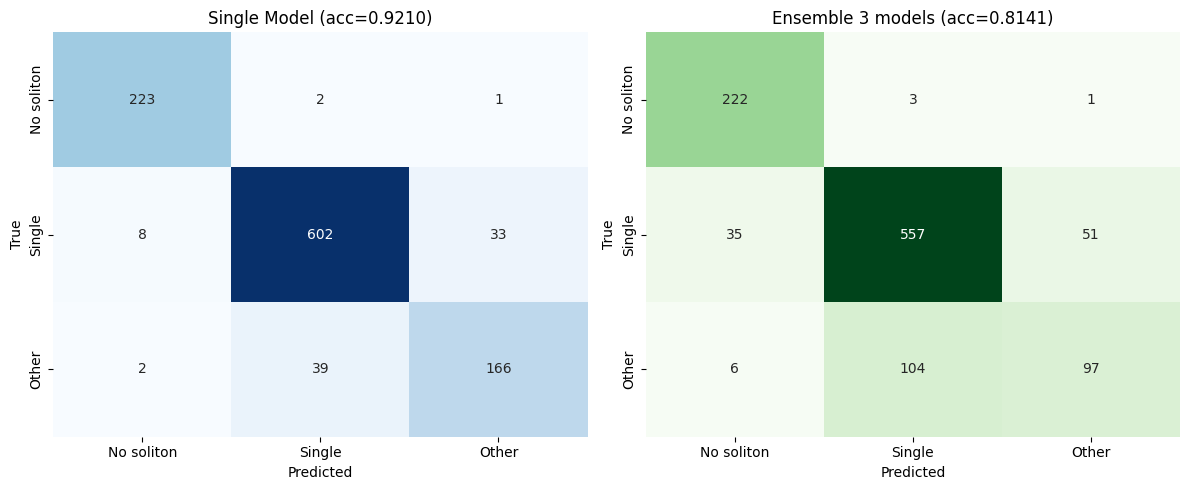

In [111]:
# --- Confusion Matrices: Single vs Ensemble ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Single model (baseline from earlier cell)
cm_single = confusion_matrix(y_true, y_pred)
sns.heatmap(cm_single, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['No soliton', 'Single', 'Other'],
            yticklabels=['No soliton', 'Single', 'Other'])
axes[0].set_title(f'Single Model (acc={acc:.4f})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Ensemble
cm_ens = confusion_matrix(ens_labels, ens_preds)
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['No soliton', 'Single', 'Other'],
            yticklabels=['No soliton', 'Single', 'Other'])
axes[1].set_title(f'Ensemble {N_FOLDS} models (acc={ens_acc:.4f})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig("ensembleconfusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()

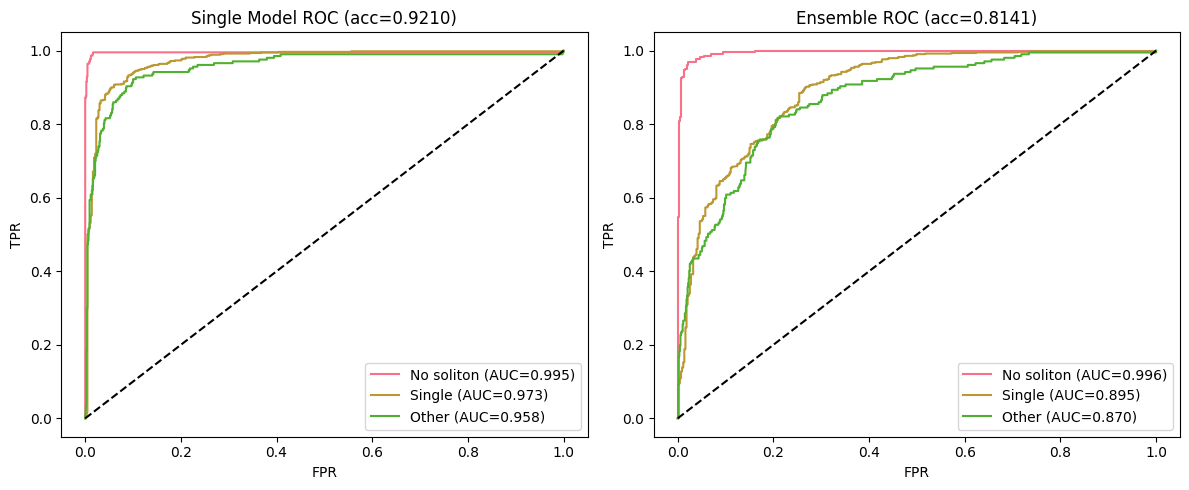

SUMMARY
Single split:    0.9210
CV mean:         0.7927 ± 0.0132
Ensemble:        0.8141
Saved 3 fold models


In [112]:
# --- ROC Curves: Single vs Ensemble ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
class_names = ['No soliton', 'Single', 'Other']

# Single model ROC
y_true_bin_single = label_binarize(y_true, classes=[0, 1, 2])
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin_single[:, i], y_probs[:, i])
    auc = roc_auc_score(y_true_bin_single[:, i], y_probs[:, i])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title(f'Single Model ROC (acc={acc:.4f})')
axes[0].legend()

# Ensemble ROC
y_true_bin_ens = label_binarize(ens_labels, classes=[0, 1, 2])
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin_ens[:, i], ens_probs[:, i])
    auc = roc_auc_score(y_true_bin_ens[:, i], ens_probs[:, i])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title(f'Ensemble ROC (acc={ens_acc:.4f})')
axes[1].legend()

plt.tight_layout()
plt.savefig("ensembleroc_curves.png", dpi=300, bbox_inches='tight')
plt.show()



# --- Save ---
for i, m in enumerate(fold_models):
    torch.save(m.state_dict(), f'levit192_mixed_fold_{i+1}ensemble.pth')

print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Single split:    {acc:.4f}")
print(f"CV mean:         {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Ensemble:        {ens_acc:.4f}")
print(f"Saved {N_FOLDS} fold models")

## Note on the ensemble result

Cross-validation on this dataset tends to underperform compared to training on the full dataset because each fold contains only a fraction of the already limited real data. This effect is amplified by the uneven distribution of simulated data across folds (Class 0: 600, Class 1: 1200, Class 2: 1800), which leads to inconsistent decision boundaries. As a result, models trained on individual folds often disagree, reducing ensemble performance and lowering the apparent CV accuracy. 

When the model is trained on the full dataset with simulated augmentation, it can more consistently achieve high accuracy (>90%).

I think that the baseline model is capable of high performance, as repeated training on the full dataset with simulated augmentation consistently achieves accuracies above 90%. 
The observed drop in CV and ensemble performance is primarily due to limited data per fold and uneven class coverage, which make the learned boundaries unstable. In practice, training on the full dataset allows the model to see all classes more evenly, stabilizing decision boundaries and enabling higher accuracy.

## Valley of mistakes - CLASSIFIER

these are just some code and runs that are different that i thought was noteworthy to collect but you dont need to look at it

This result was really good but the validation curve was all over the place( oscillating)
Phase 1: Head + adapter only

  10/30 | train=0.8586 val=0.7872 | lr=7.53e-04
  15/30 | train=0.8624 val=0.7900 | lr=5.05e-04
  20/30 | train=0.8681 val=0.7983 | lr=2.58e-04
  25/30 | train=0.8637 val=0.7872 | lr=7.63e-05
  30/30 | train=0.8693 val=0.8011 | lr=1.00e-05

Phase 2: Full fine-tuning
Unfrozen: 10,286,656 trainable parameters
  5/50 | train=0.8903 val=0.8253 | backbone_lr=4.88e-06
  10/50 | train=0.9098 val=0.8717 | backbone_lr=4.53e-06
  15/50 | train=0.9238 val=0.8913 | backbone_lr=3.98e-06
  20/50 | train=0.9376 val=0.8913 | backbone_lr=3.29e-06
  25/50 | train=0.9462 val=0.9117 | backbone_lr=2.53e-06
  30/50 | train=0.9427 val=0.9126 | backbone_lr=1.76e-06
  35/50 | train=0.9520 val=0.9061 | backbone_lr=1.07e-06
  40/50 | train=0.9503 val=0.9182 | backbone_lr=5.23e-07
  45/50 | train=0.9548 val=0.9191 | backbone_lr=1.71e-07
  50/50 | train=0.9539 val=0.9191 | backbone_lr=5.00e-08

Best val accuracy: 0.9229

Mixed training accuracy: 0.9229
              precision    recall  f1-score   support

  No soliton     0.9534    0.9956    0.9740       226
      Single     0.9337    0.9425    0.9381       643
       Other     0.8482    0.7826    0.8141       207

    accuracy                         0.9229      1076
   macro avg     0.9118    0.9069    0.9087      1076
weighted avg     0.9214    0.9229    0.9218      1076

In [109]:
# ============================================================
# Cell 9: Three-Stage Training Function
# ============================================================

def three_stage_train(model, sim_loader, real_train_loader, real_val_loader, device,
                      stage1_epochs=15, stage2_epochs=25, stage3_epochs=50,
                      stage1_lr=1e-3,
                      stage2_backbone_lr=1e-5, stage2_head_lr=1e-4,
                      stage3_backbone_lr=5e-6, stage3_head_lr=5e-5):
    """
    Stage 1: Adapter+head on SIMULATED (backbone frozen)
    Stage 2: Full model on SIMULATED (backbone unfrozen)
    Stage 3: Full model on REAL (lower LR, early stopping)
    """
    history = {'stage': [], 'epoch': [], 'train_loss': [], 'train_acc': [],
               'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    best_state = None

    # Build criteria
    sim_labels_all = []
    for _, l in sim_loader:
        sim_labels_all.extend(l.numpy())
    sim_counts = np.bincount(sim_labels_all)
    sim_weights = 1.0 / sim_counts
    sim_weights = sim_weights / sim_weights.sum() * len(sim_counts)
    sim_criterion = nn.CrossEntropyLoss(
        weight=torch.FloatTensor(sim_weights).to(device)
    )

    real_val_labels = []
    for _, l in real_val_loader:
        real_val_labels.extend(l.numpy())
    rv_counts = np.bincount(real_val_labels)
    rv_weights = 1.0 / rv_counts
    rv_weights = rv_weights / rv_weights.sum() * len(rv_counts)
    real_val_criterion = nn.CrossEntropyLoss(
        weight=torch.FloatTensor(rv_weights).to(device)
    )

    # ---- Stage 1 ----
    print("=" * 60)
    print("Stage 1: Adapter+head on SIMULATED (backbone frozen)")
    print("=" * 60)

    opt = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=stage1_lr, weight_decay=1e-4
    )
    sched = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=stage1_epochs, eta_min=stage1_lr * 0.01
    )

    for epoch in range(stage1_epochs):
        tl, ta = train_epoch(model, sim_loader, sim_criterion, opt, device)
        vl, va, _, _, _ = eval_model(model, real_val_loader, real_val_criterion, device)
        sched.step()

        history['stage'].append(1)
        history['epoch'].append(epoch)
        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)

        if va > best_val_acc:
            best_val_acc = va
            best_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 5 == 0:
            print(f"  {epoch+1}/{stage1_epochs} | "
                  f"sim_train={ta:.4f} real_val={va:.4f} | "
                  f"lr={opt.param_groups[0]['lr']:.2e}")

    print(f"  Stage 1 best real_val: {best_val_acc:.4f}")

    # ---- Stage 2 ----
    print(f"\n{'='*60}")
    print("Stage 2: Full model on SIMULATED (backbone unfrozen)")
    print("=" * 60)

    model.load_state_dict(best_state)
    param_groups = unfreeze_model(model, stage2_backbone_lr, stage2_head_lr)
    opt = optim.AdamW(param_groups, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=stage2_epochs, eta_min=stage2_backbone_lr * 0.01
    )

    for epoch in range(stage2_epochs):
        tl, ta = train_epoch(model, sim_loader, sim_criterion, opt, device)
        vl, va, _, _, _ = eval_model(model, real_val_loader, real_val_criterion, device)
        sched.step()

        history['stage'].append(2)
        history['epoch'].append(stage1_epochs + epoch)
        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)

        if va > best_val_acc:
            best_val_acc = va
            best_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 5 == 0:
            print(f"  {epoch+1}/{stage2_epochs} | "
                  f"sim_train={ta:.4f} real_val={va:.4f} | "
                  f"backbone_lr={opt.param_groups[0]['lr']:.2e}")

    print(f"  Stage 2 best real_val: {best_val_acc:.4f}")
    torch.save(best_state, 'levit192_after_sim_pretrain.pth')

    # ---- Stage 3 ----
    print(f"\n{'='*60}")
    print("Stage 3: Fine-tune on REAL data")
    print("=" * 60)

    model.load_state_dict(best_state)

    real_train_labels = []
    for _, l in real_train_loader:
        real_train_labels.extend(l.numpy())
    rt_counts = np.bincount(real_train_labels)
    rt_weights = 1.0 / rt_counts
    rt_weights = rt_weights / rt_weights.sum() * len(rt_counts)
    rt_criterion = nn.CrossEntropyLoss(
        weight=torch.FloatTensor(rt_weights).to(device)
    )

    param_groups = unfreeze_model(model, stage3_backbone_lr, stage3_head_lr)
    opt = optim.AdamW(param_groups, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=stage3_epochs, eta_min=stage3_backbone_lr * 0.01
    )
    patience_counter = 0
    PATIENCE = 15

    for epoch in range(stage3_epochs):
        tl, ta = train_epoch(model, real_train_loader, rt_criterion, opt, device)
        vl, va, _, _, _ = eval_model(model, real_val_loader, real_val_criterion, device)
        sched.step()

        history['stage'].append(3)
        history['epoch'].append(stage1_epochs + stage2_epochs + epoch)
        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)

        if va > best_val_acc:
            best_val_acc = va
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

        if (epoch + 1) % 5 == 0:
            print(f"  {epoch+1}/{stage3_epochs} | "
                  f"real_train={ta:.4f} real_val={va:.4f} | "
                  f"backbone_lr={opt.param_groups[0]['lr']:.2e}")

    model.load_state_dict(best_state)
    print(f"\n  Overall best val accuracy: {best_val_acc:.4f}")
    return history

In [ ]:
'''Training purely on simulated data is overfitting. doesnt understand actual data'''
print("=" * 60)
print("THREE-STAGE: cGAN Pretrain → Real Fine-tune")
print("=" * 60)

model = create_levit_1ch(
    num_classes=3, model_name='levit_192.fb_dist_in1k',
    freeze_backbone=True, adapter_dim=192
).to(device)

sim_ds = BECDataset(sim_images, sim_labels, augment=True)
real_train_ds = BECDataset(X_train, y_train, augment=True)
test_ds = BECDataset(X_test, y_test, augment=False)

sim_loader = DataLoader(sim_ds, batch_size=16, shuffle=True, num_workers=2)
real_train_loader = DataLoader(real_train_ds, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)

print(f"Simulated: {len(sim_ds)} samples")
print(f"Real train: {len(real_train_ds)} samples")
print(f"Real test: {len(test_ds)} samples")

history = three_stage_train(
    model, sim_loader, real_train_loader, test_loader, device
)

criterion = nn.CrossEntropyLoss()
_, acc, y_pred, y_true, y_probs = eval_model(model, test_loader, criterion, device)
print(f"\nFinal test accuracy: {acc:.4f}")
print(classification_report(y_true, y_pred, digits=4,
      target_names=['No soliton', 'Single', 'Other']))

torch.save(model.state_dict(), 'levit192_cgan_pretrain_final.pth')
print("Saved final model")


'''============================================================
THREE-STAGE: cGAN Pretrain → Real Fine-tune
============================================================

model.safetensors: 100%
 44.1M/44.1M [00:25<00:00, 4.14MB/s]

  Averaged stem.conv1.linear.weight: torch.Size([24, 3, 3, 3]) → torch.Size([24, 1, 3, 3])
  Backbone feature dim: 384
levit_192.fb_dist_in1k (1ch+adapter): 10,286,656 total, 111,555 trainable
Simulated: 3000 samples
Real train: 647 samples
Real test: 162 samples
============================================================
Stage 1: Adapter+head on SIMULATED (backbone frozen)
============================================================
  5/15 | sim_train=0.9540 real_val=0.5926 | lr=7.52e-04
  10/15 | sim_train=0.9650 real_val=0.6173 | lr=2.58e-04
  15/15 | sim_train=0.9723 real_val=0.4321 | lr=1.00e-05
  Stage 1 best real_val: 0.6173

============================================================
Stage 2: Full model on SIMULATED (backbone unfrozen)
============================================================
Unfrozen: 10,286,656 trainable parameters
  5/25 | sim_train=0.9840 real_val=0.3519 | backbone_lr=9.05e-06
  10/25 | sim_train=0.9860 real_val=0.4444 | backbone_lr=6.58e-06
'''